In [5]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())
print(df['Churn'].value_counts())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [6]:
import sqlite3
conn = sqlite3.connect(':memory:')
df.to_sql('customers', conn, index=False, if_exists='replace')
print("Database ready!")

Database ready!


In [7]:
query = """
SELECT Churn, COUNT(*) as total_customers
FROM customers
GROUP BY Churn
"""
result = pd.read_sql_query(query, conn)
print(result)

  Churn  total_customers
0    No             5174
1   Yes             1869


In [8]:
query = """
SELECT Contract,
       COUNT(*) as total,
       SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned,
       ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

         Contract  total  churned  churn_rate_pct
0  Month-to-month   3875     1655           42.71
1        One year   1473      166           11.27
2        Two year   1695       48            2.83


In [9]:
query = """
SELECT Churn,
       ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charges,
       ROUND(AVG(tenure), 2) as avg_tenure_months
FROM customers
GROUP BY Churn
"""
result = pd.read_sql_query(query, conn)
print(result)

  Churn  avg_monthly_charges  avg_tenure_months
0    No                61.27              37.57
1   Yes                74.44              17.98


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

/tmp/ipykernel_4434/3288020613.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


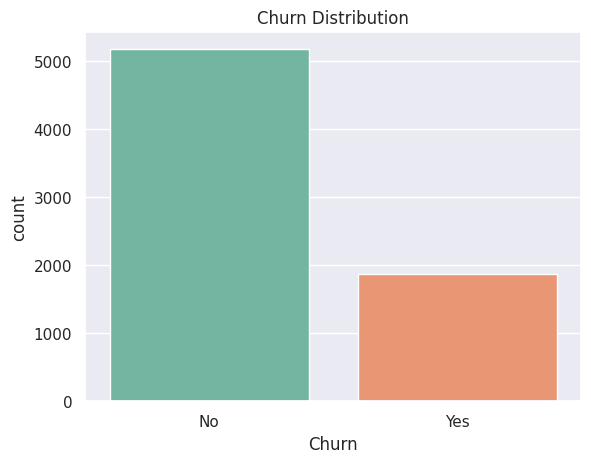

In [11]:
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.show()

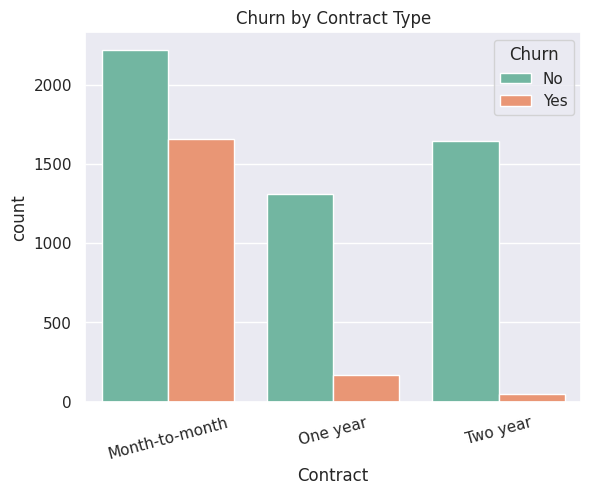

In [12]:
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

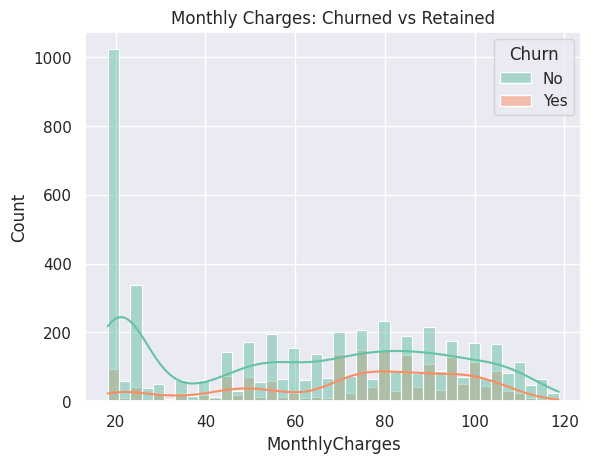

In [13]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=40, kde=True, palette='Set2')
plt.title('Monthly Charges: Churned vs Retained')
plt.show()

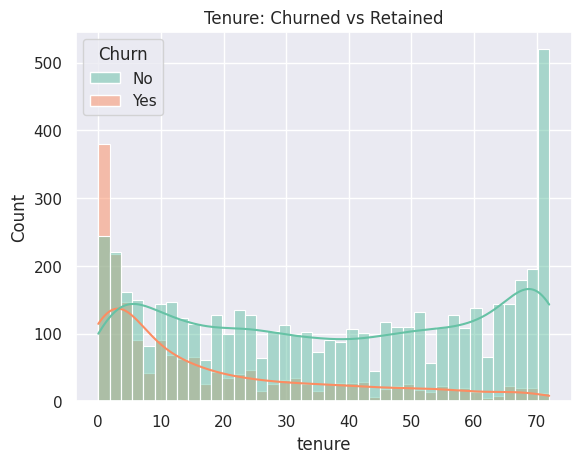

In [14]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=40, kde=True, palette='Set2')
plt.title('Tenure: Churned vs Retained')
plt.show()

In [15]:
print(df.isnull().sum())
print(df.dtypes)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      f

In [16]:
print(df['TotalCharges'].unique()[:20])
blank_rows = df[df['TotalCharges'] == ' ']
print(f"Blank rows: {len(blank_rows)}")

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']
Blank rows: 11


In [17]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', float('nan'))
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df.dropna(inplace=True)
print(df.shape)
print(df['TotalCharges'].dtype)

(7032, 21)
float64


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=['MultipleLines', 'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection', 'TechSupport',
                                  'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'])

df.drop('customerID', axis=1, inplace=True)
print(df.shape)
print(df.head())

(7032, 41)
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   StreamingMovies_No  StreamingMovies_No internet service  \
0                True                                False   
1                True                          

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 5625
Testing samples: 1407


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC Score: 0.8318976450916546


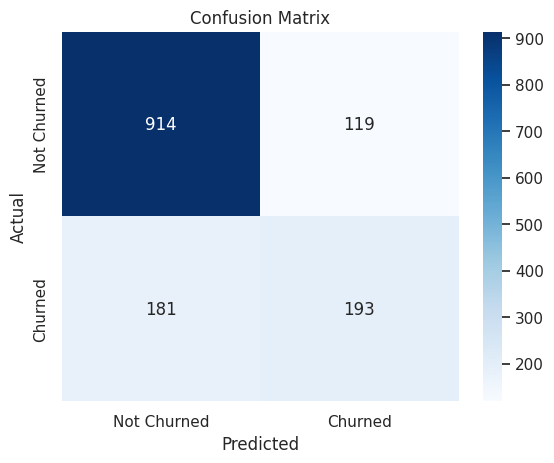

In [23]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

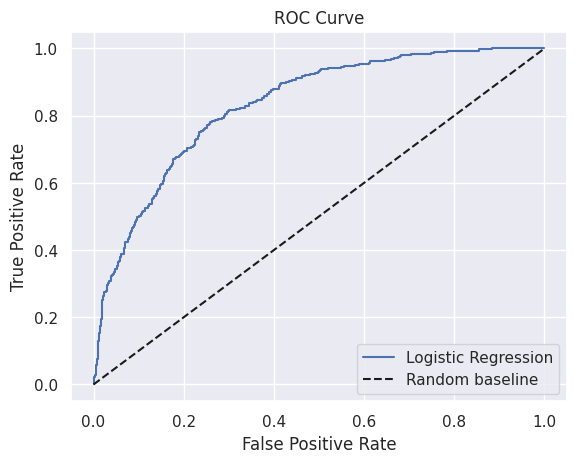

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [25]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

